In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
ROLL_NUMBER = 51
np.random.seed(ROLL_NUMBER)
sales_data = np.random.randint(1000, 5001, size=(12, 4))
columns = ["Electronics", "Clothing", "Home & Kitchen", "Sports"]
months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
          "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
df = pd.DataFrame(sales_data, columns=columns, index=months)
df

,Electronics,Clothing,Home & Kitchen,Sports
Jan,4070,3105,1485,2760
Feb,2733,3576,4989,4806
Mar,2460,4433,3981,1634
Apr,1878,1549,3620,1862
May,3076,4924,4748,2187
Jun,1923,4100,4498,3932
Jul,1906,3054,1793,3465
Aug,1461,4572,4376,4096
Sep,3728,4126,1717,3932
Oct,4100,3885,2593,3834


The random seed is set using the roll number. Monthly sales data for four product categories is generated using NumPy with values between 1000 and 5000. The data is then converted into a Pandas DataFrame with months as the index for further analysis.

In [2]:
df.head(), df.describe()

(     Electronics  Clothing  Home & Kitchen  Sports
 Jan         4070      3105            1485    2760
 Feb         2733      3576            4989    4806
 Mar         2460      4433            3981    1634
 Apr         1878      1549            3620    1862
 May         3076      4924            4748    2187,
        Electronics     Clothing  Home & Kitchen       Sports
 count    12.000000    12.000000       12.000000    12.000000
 mean   2660.333333  3749.166667     3373.500000  3387.083333
 std    1012.832332   893.849167     1241.732843  1072.720285
 min    1191.000000  1549.000000     1485.000000  1634.000000
 25%    1899.000000  3415.500000     2393.000000  2616.750000
 50%    2596.500000  3992.500000     3687.500000  3649.500000
 75%    3480.500000  4218.500000     4406.500000  3973.000000
 max    4100.000000  4924.000000     4989.000000  4837.000000)

In [3]:
total_sales_category = df.sum()
total_sales_month = df.sum(axis=1)
total_sales_category, total_sales_month

(Electronics       31924
 Clothing          44990
 Home & Kitchen    40482
 Sports            40645
 dtype: int64,
 Jan    11420
 Feb    16104
 Mar    12508
 Apr     8909
 May    14935
 Jun    14453
 Jul    10218
 Aug    14505
 Sep    13503
 Oct    14412
 Nov    12393
 Dec    14681
 dtype: int64)

In [4]:
growth_per_category = df.pct_change().mean()
growth_per_category

,0
Electronics,0.195527
Clothing,0.159475
Home & Kitchen,0.299566
Sports,0.138011


In [5]:
df["Total Sales"] = df.sum(axis=1)
df["Growth Rate"] = df["Total Sales"].pct_change() * 100
df

,Electronics,Clothing,Home & Kitchen,Sports,Total Sales,Growth Rate
Jan,4070,3105,1485,2760,11420,NaN
Feb,2733,3576,4989,4806,16104,41.015762
Mar,2460,4433,3981,1634,12508,-22.329856
Apr,1878,1549,3620,1862,8909,-28.773585
May,3076,4924,4748,2187,14935,67.639466
Jun,1923,4100,4498,3932,14453,-3.227318
Jul,1906,3054,1793,3465,10218,-29.301875
Aug,1461,4572,4376,4096,14505,41.955373
Sep,3728,4126,1717,3932,13503,-6.907963
Oct,4100,3885,2593,3834,14412,6.731837


In [6]:
df_discounted = df.copy()
if ROLL_NUMBER % 2 == 0:
    df_discounted["Electronics"] = df_discounted["Electronics"] * 0.9
    discount_applied = "10% discount applied to Electronics"
else:
    df_discounted["Clothing"] = df_discounted["Clothing"] * 0.85
    discount_applied = "15% discount applied to Clothing"
discount_applied, df_discounted.head()

('15% discount applied to Clothing',
      Electronics  Clothing  Home & Kitchen  Sports  Total Sales  Growth Rate
 Jan         4070   2639.25            1485    2760        11420          NaN
 Feb         2733   3039.60            4989    4806        16104    41.015762
 Mar         2460   3768.05            3981    1634        12508   -22.329856
 Apr         1878   1316.65            3620    1862         8909   -28.773585
 May         3076   4185.40            4748    2187        14935    67.639466)

From cell 5-9, here computed total sales, growth rates,and also applied discounts based on whether the roll number is even or odd.

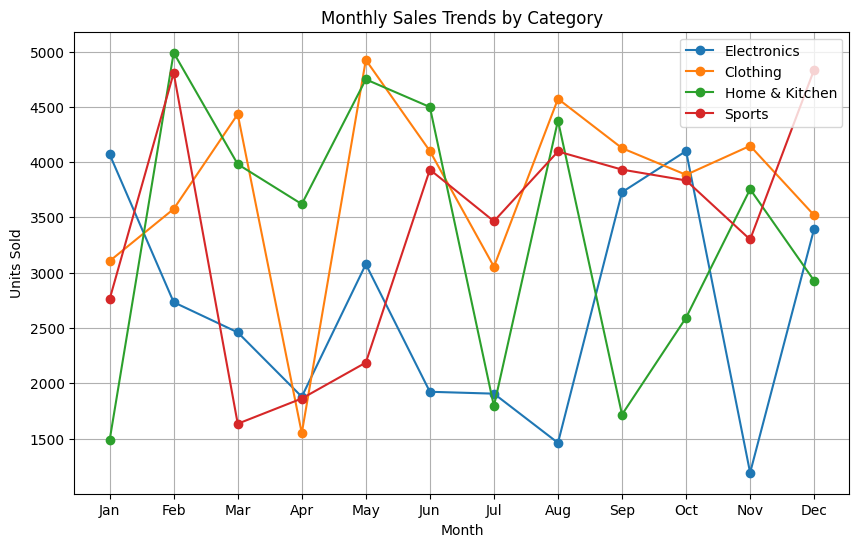

In [7]:
plt.figure(figsize=(10,6))
for col in ["Electronics", "Clothing", "Home & Kitchen", "Sports"]:
    plt.plot(df.index, df[col], marker='o', label=col)
plt.title("Monthly Sales Trends by Category")
plt.xlabel("Month")
plt.ylabel("Units Sold")
plt.legend()
plt.grid(True)
plt.show()

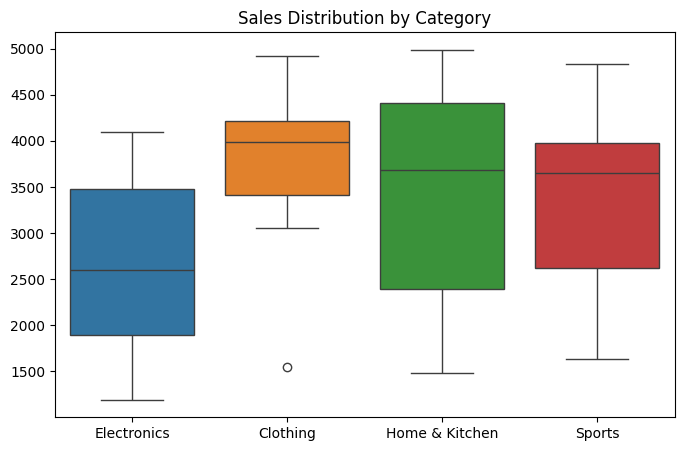

In [8]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df[["Electronics", "Clothing", "Home & Kitchen", "Sports"]])
plt.title("Sales Distribution by Category")
plt.show()

In cell 9, the line plot shows trends over months, while in the cell 11, the box plot shows the distribution and variability of sales across categories.

In [9]:
array = np.array([[1, -2, 3], [-4, 5, -6]])
abs_array = np.abs(array)
percentiles_flat = np.percentile(array.flatten(), [25, 50, 75])
percentiles_col = np.percentile(array, [25, 50, 75], axis=0)
percentiles_row = np.percentile(array, [25, 50, 75], axis=1)
mean_flat = np.mean(array)
median_flat = np.median(array)
std_flat = np.std(array)
mean_col = np.mean(array, axis=0)
median_col = np.median(array, axis=0)
std_col = np.std(array, axis=0)
mean_row = np.mean(array, axis=1)
median_row = np.median(array, axis=1)
std_row = np.std(array, axis=1)
abs_array, percentiles_flat, percentiles_col, percentiles_row, mean_flat, median_flat, std_flat

(array([[1, 2, 3],
        [4, 5, 6]]),
 array([-3.5, -0.5,  2.5]),
 array([[-2.75, -0.25, -3.75],
        [-1.5 ,  1.5 , -1.5 ],
        [-0.25,  3.25,  0.75]]),
 array([[-0.5, -5. ],
        [ 1. , -4. ],
        [ 2. ,  0.5]]),
 np.float64(-0.5),
 np.float64(-0.5),
 np.float64(3.8622100754188224))

In cell 12, element-wise absolute values, percentiles, mean, median and standard deviation are computed for the given NumPy array. These values are calculated for the flattened array as well as for the rows and columns to analyze data distribution and variability.

In [10]:
a = np.array([-1.8, -1.6, -0.5, 0.5, 1.6, 1.8, 3.0])
floor_vals = np.floor(a)
ceil_vals = np.ceil(a)
trunc_vals = np.trunc(a)
round_vals = np.round(a)
floor_vals, ceil_vals, trunc_vals, round_vals

(array([-2., -2., -1.,  0.,  1.,  1.,  3.]),
 array([-1., -1., -0.,  1.,  2.,  2.,  3.]),
 array([-1., -1., -0.,  0.,  1.,  1.,  3.]),
 array([-2., -2., -0.,  0.,  2.,  2.,  3.]))

In [11]:
lst = [10, 20, 30, 40]
i, j = 1, 3
temp = lst[i]
lst[i] = lst[j]
lst[j] = temp
lst


[10, 40, 30, 20]

In [12]:
s = {10, 20, 30, 40}
lst = list(s)
i, j = 0, 2
temp = lst[i]
lst[i] = lst[j]
lst[j] = temp
s_swapped = set(lst)
s_swapped

{10, 20, 30, 40}